### [K線捕手](https://www.facebook.com/kevinyang20180801)  
[今天早中晚都有行程](https://www.facebook.com/kevinyang20180801/posts/pfbid0FvAjNr8bSNYcBtqH3ZsX91JAXSNMBdh4yqWEf6Mfe1Z4ABWoKkAJWvLg6fAdfcBcl)，所以不會有太多訊息，大家加油!  

期貨小漲：  
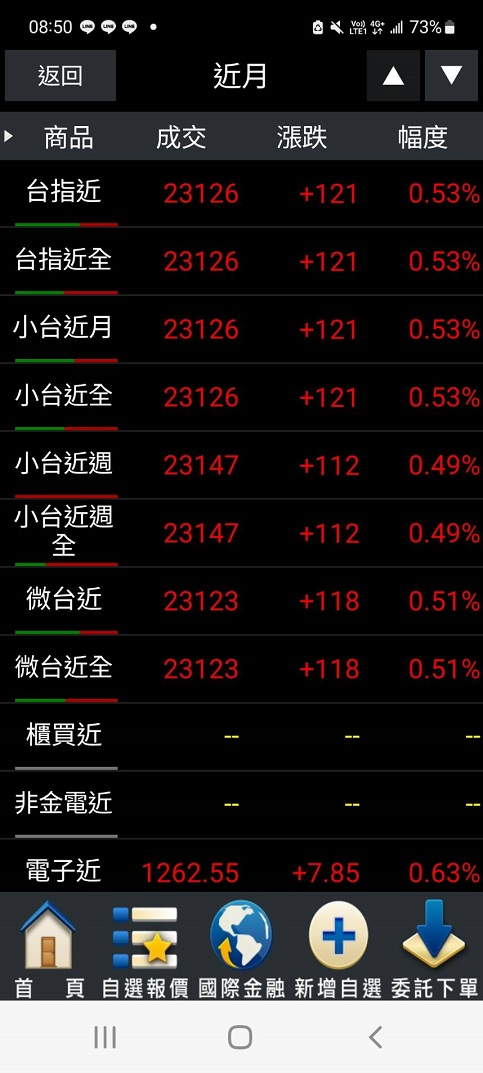  
  
加權指數過高，櫃買指數還没：  
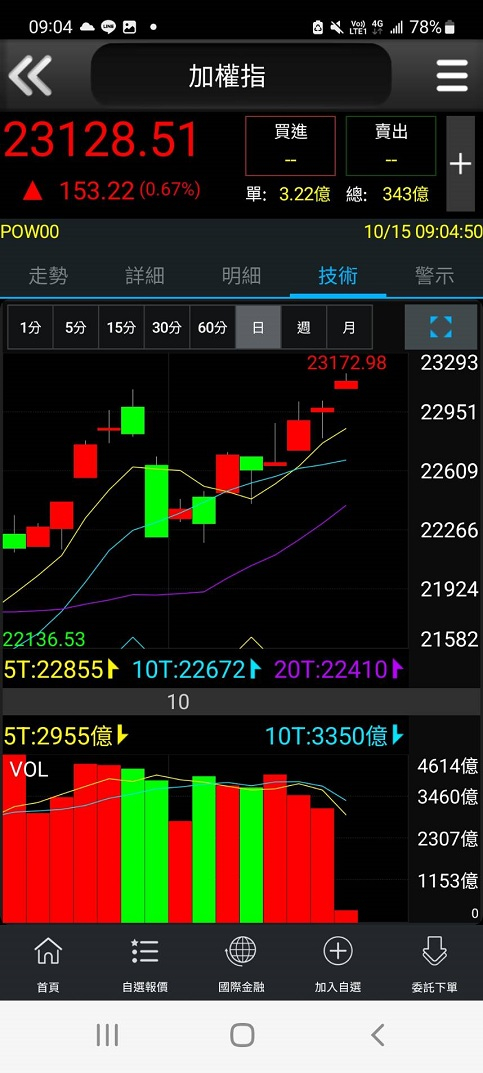  
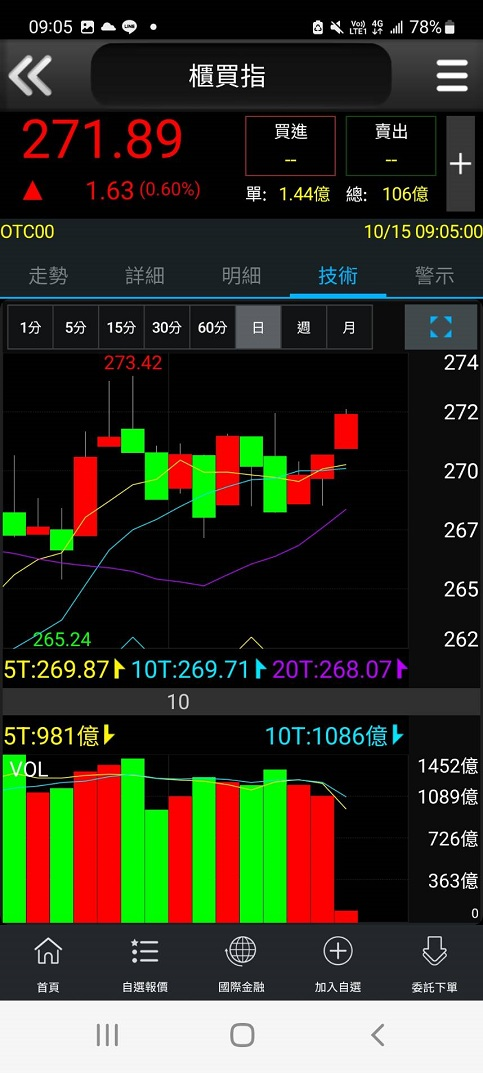  
  
【周末影音解盤】  
道瓊指數續創新高，能否有效帶動台股表現？3套劇本因應未來走勢和操作。未來台股能否突破近一季的盤局，要觀察哪4大關鍵訊號？   
完整教學內容，詳見影音解盤~  
https://fb.watch/vbgtbzaT7L/  
還沒看過週末解盤，可以再複習一下。  
  
加權指數貢獻排行：  
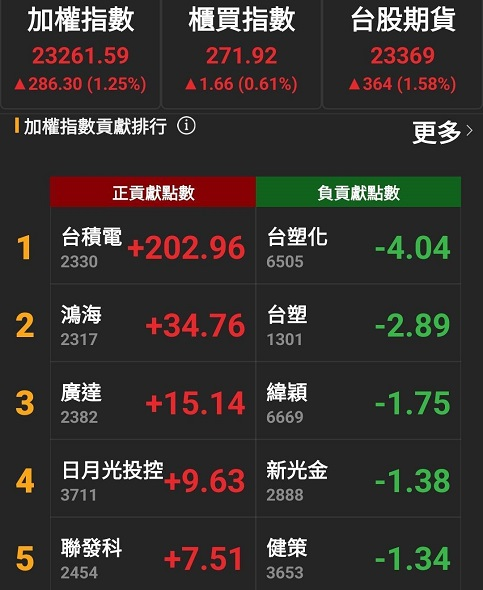  

3081聯亞噴出段操作結束：  
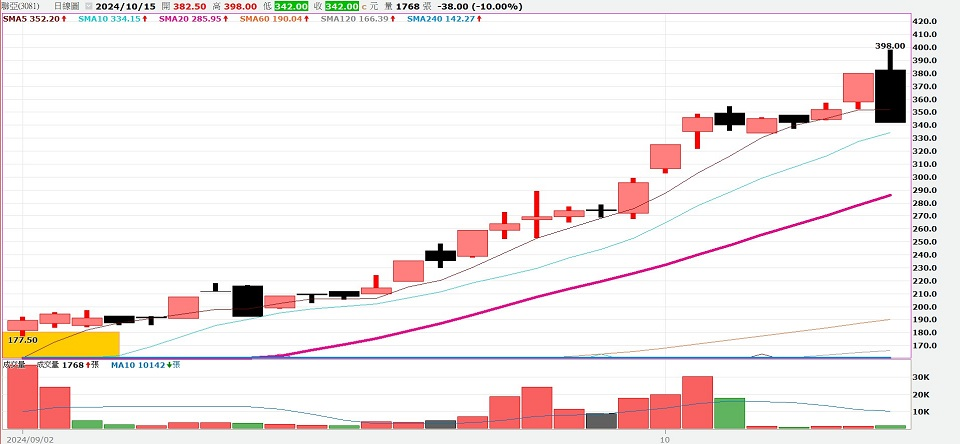  

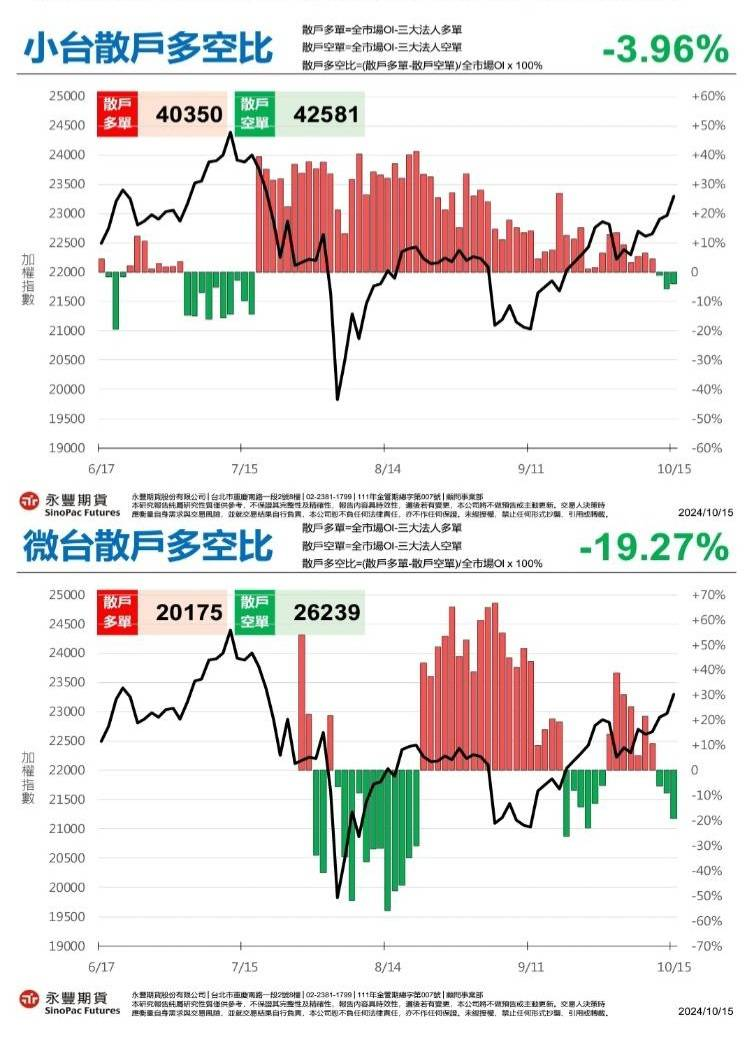  
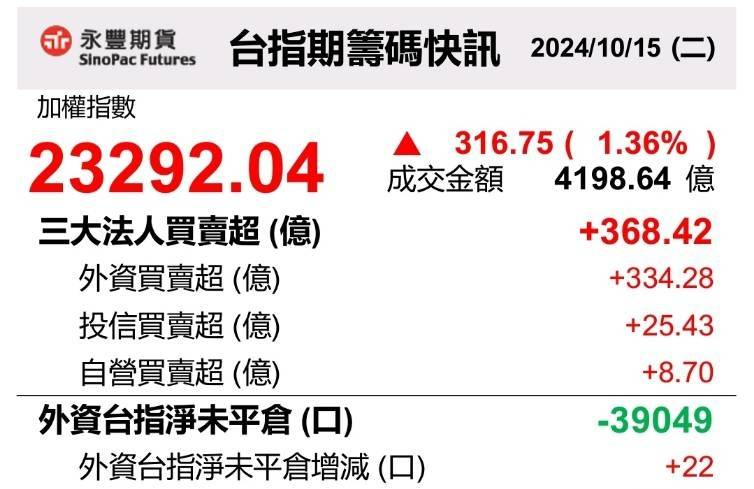  

### 本日進度  
* 暫時空手，觀察後續盤勢發展。  
* 觀察股：連展投控(3710)  
  - 回測頸線支撐。(折返程度接近跌停)  

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import mplfinance as mpf
import numpy as np

In [2]:
##### 使用2022年7月6日到今日收盤(2024年10月15日)之日線圖資料 #####

# 載入從「好神通PLUS」輸出的Excel檔
df = pd.read_excel('./data/SINO_3710_241015.xlsx')

# 保存K棒的基本資訊(開、高、低、收、量)
df_k_line = df.drop(columns=['SMA5','SMA10','SMA20','SMA60','SMA120','SMA240','MA5','MA10'])

# 保存價的均線
df_sma = df.drop(columns=['開盤價','最高價','最低價','收盤價','成交量','MA5','MA10']) 

# 將K棒的Columns的名稱由中文改為英文
df_k_line = df_k_line.rename(columns={'時間':'Date','開盤價':'Open','最高價':'High','最低價':'Low','收盤價':'Close','成交量':'Volume'})

# 將價的均線的Columns的名稱由中文改為英文
df_sma = df_sma.rename(columns={'時間':'Date'})

# 將K棒的Date設為Index
df_k_line.set_index(df_k_line['Date'],inplace=True)
df_k_line = df_k_line.drop(columns=['Date'])

# 將價的均線的Date設為Index
df_sma.set_index(df_sma['Date'],inplace=True)
df_sma = df_sma.drop(columns=['Date'])

In [3]:
# 設定頸線
neckline_start_date = '2022-09-26'
neckline_end_date = df_k_line.iloc[-1].name.strftime("%Y-%m-%d")
neckline_price = df_k_line.loc['2023-02-09']['Close']
breakout_date = '2024-10-09'

# 估算目標價
bottom_price_date = '2023-08-28'
bottom_price = df_k_line.loc[bottom_price_date]['Close']
target_price = (neckline_price - bottom_price) + neckline_price
print('頸線價格 ＝ {:.2f}元 ， 底部最低價格 ＝ {:.2f}元 ； 估算目標價 ＝ {:.2f}元（ 今日收盤價 ＝ {:.2f}元 ）'.format(neckline_price,bottom_price,target_price,df_k_line.iloc[-1]['Close']))

頸線價格 ＝ 13.15元 ， 底部最低價格 ＝ 9.13元 ； 估算目標價 ＝ 17.17元（ 今日收盤價 ＝ 14.70元 ）


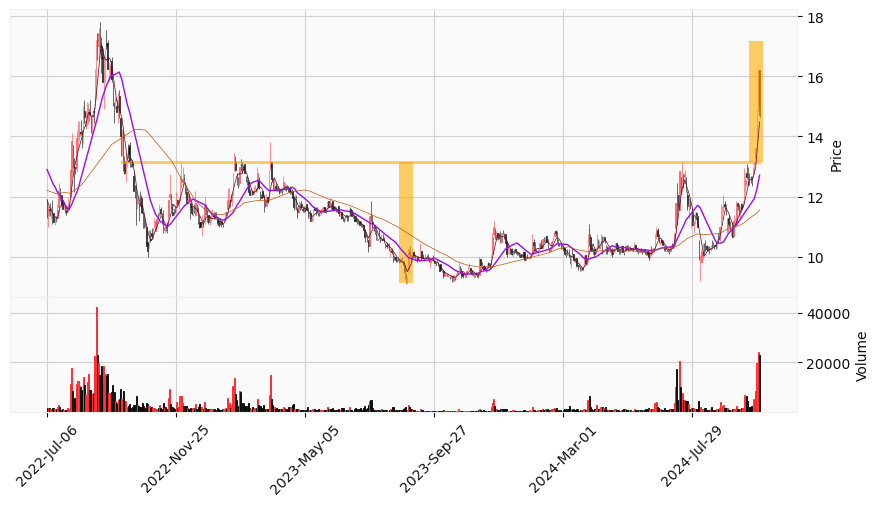

In [4]:
# 設定K線格式
mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

# 設定頸線
seq_of_seq_of_points=[
    [(neckline_start_date,neckline_price),(neckline_end_date,neckline_price)],
    [(bottom_price_date,bottom_price),(bottom_price_date,neckline_price)],
    [(breakout_date,neckline_price),(breakout_date,target_price)]
                     ]

# 設定均線
added_plots={
    "SMA5": mpf.make_addplot(df_sma['SMA5'],width=0.5,color='xkcd:maroon'),
    "SMA20": mpf.make_addplot(df_sma['SMA20'],width=1.0,color='xkcd:violet'),
    "SMA60": mpf.make_addplot(df_sma['SMA60'],width=0.5,color='xkcd:dark orange')
    
            }

# 繪製K線圖
kwargs = dict(type='candle', style=s, figratio=(19,10), volume=True,addplot=list(added_plots.values()), alines=dict(alines=seq_of_seq_of_points, linewidths=(1.0,10,10), colors='xkcd:orange yellow', alpha=0.6), warn_too_much_data=1100)
mpf.plot(df_k_line,**kwargs)

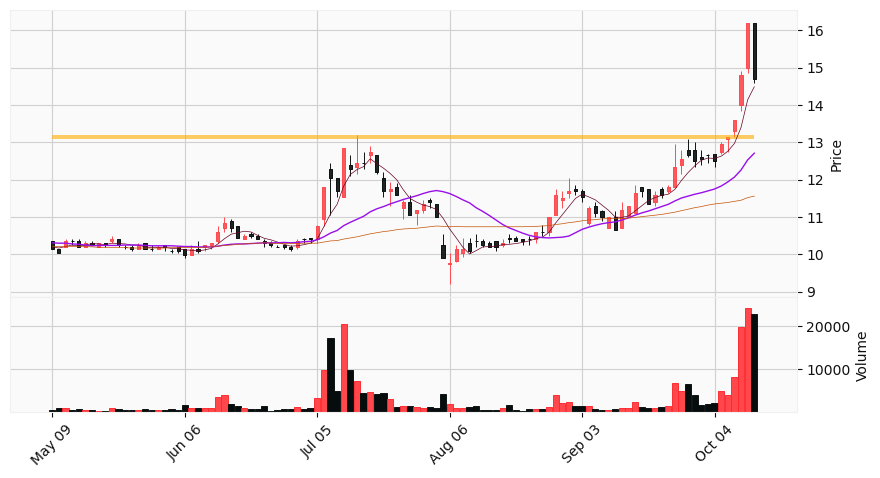

In [5]:
# 取區間範圍
df_k_line_range = df_k_line['2024-05-09':]
df_sma_range = df_sma['2024-05-09':]
neckline_start_date = df_k_line_range.iloc[0].name.strftime("%Y-%m-%d")
neckline_end_date = df_k_line_range.iloc[-1].name.strftime("%Y-%m-%d")

# 設定K線格式
mc = mpf.make_marketcolors(up='xkcd:light red', down='xkcd:almost black', inherit=True)
s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)

# 設定頸線
seq_of_seq_of_points=[
    [(neckline_start_date,neckline_price),(neckline_end_date,neckline_price)]]
    
# 設定均線
added_plots={
    "SMA5": mpf.make_addplot(df_sma_range['SMA5'],width=0.5,color='xkcd:maroon'),
    "SMA20": mpf.make_addplot(df_sma_range['SMA20'],width=1.0,color='xkcd:violet'),
    "SMA60": mpf.make_addplot(df_sma_range['SMA60'],width=0.5,color='xkcd:dark orange')
            }

# 繪製K線圖
kwargs = dict(type='candle', style=s, figratio=(19,10), volume=True,addplot=list(added_plots.values()), alines=dict(alines=seq_of_seq_of_points, linewidths=(1.5,1.0,1.0), colors=('xkcd:orange yellow','xkcd:red','xkcd:blue'), alpha=0.6))
mpf.plot(df_k_line_range,**kwargs)